<a href="https://colab.research.google.com/github/nazaninbondarian/MachineLearning2024/blob/main/Second_Steps/PK_PD_Data_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install --upgrade pip

In [49]:
!pip install vitaldb pandas

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import vitaldb

In [52]:
url = "https://api.vitaldb.net/cases"

clinical = pd.read_csv(url)

patient_info = clinical[
    ['caseid',
     'age',
     'sex',
     'height',
     'weight',
     'bmi',
     'asa']
]

print(patient_info.head(10))

   caseid   age sex  height  weight   bmi  asa
0       1  77.0   M   160.2   67.50  26.3  2.0
1       2  54.0   M   167.3   54.80  19.6  2.0
2       3  62.0   M   169.1   69.70  24.4  1.0
3       4  74.0   M   160.6   53.00  20.5  2.0
4       5  66.0   M   171.0   59.70  20.4  3.0
5       6  78.0   F   150.0   54.60  24.3  2.0
6       7  52.0   F   167.7   62.30  22.2  2.0
7       8  81.0   F   156.7   67.25  27.4  2.0
8       9  32.0   F   157.9   50.90  20.4  1.0
9      10  72.0   M   162.5   62.75  23.8  3.0


In [90]:
# جستجوی بیمار
patients = clinical[
    (clinical["age"] == 55) &
    (clinical["weight"] >= 70) &
    (clinical["weight"] <= 80) &
    (clinical["height"] >= 170) &
    (clinical["height"] <= 180) &
    (clinical["sex"] == "M")      # در VitalDB معمولاً M یا F است
]

print(
    patients[
        ["caseid", "age", "sex", "height", "weight", "bmi", "asa"]
    ]
)

      caseid   age sex  height  weight   bmi  asa
256      257  55.0   M   178.4   76.05  23.9  1.0
682      683  55.0   M   170.9   76.30  26.1  2.0
1238    1239  55.0   M   172.2   71.15  24.0  2.0
1239    1240  55.0   M   177.6   79.80  25.3  2.0
1800    1801  55.0   M   175.5   71.80  23.3  2.0
2129    2130  55.0   M   170.8   71.60  24.5  3.0
3390    3391  55.0   M   176.3   70.40  22.6  1.0
3439    3440  55.0   M   180.0   70.10  21.6  2.0
3477    3478  55.0   M   172.6   72.80  24.4  2.0
4102    4103  55.0   M   174.5   75.20  24.7  2.0
4260    4261  55.0   M   172.9   76.90  25.7  2.0
4286    4287  55.0   M   171.0   71.20  24.3  3.0
4370    4371  55.0   M   172.7   72.30  24.2  1.0
4408    4409  55.0   M   172.6   73.20  24.6  2.0
5241    5242  55.0   M   171.9   74.80  25.3  1.0
5510    5511  55.0   M   172.6   73.20  24.6  2.0
6100    6101  55.0   M   171.5   74.80  25.4  1.0


In [95]:
caseid = 257
case = clinical[clinical['caseid'] == 257]

print(
    case[
        ["caseid", "age", "sex", "height", "weight", "bmi", "asa"]
    ]
)

     caseid   age sex  height  weight   bmi  asa
256     257  55.0   M   178.4   76.05  23.9  1.0


In [96]:
tracks = [
    "BIS/BIS",                    # BIS
    "Orchestra/PPF20_RATE",       # نرخ تزریق پروپوفول

    # غلظت پروپوفول
    "Orchestra/PPF20_CP",         # Plasma concentration
    "Orchestra/PPF20_CE",         # Effect-site concentration
]

data = vitaldb.load_case(
    caseid,
    tracks,
    interval=1
)

df = pd.DataFrame(
    data,
    columns=tracks
)

print(df.head())
print(df.shape)

   BIS/BIS  Orchestra/PPF20_RATE  Orchestra/PPF20_CP  Orchestra/PPF20_CE
0      NaN                   NaN                 NaN                 NaN
1      NaN                   NaN                 NaN                 NaN
2      NaN                   NaN                 NaN                 NaN
3      NaN                   NaN                 NaN                 NaN
4      0.0                   NaN                 NaN                 NaN
(16161, 4)


In [97]:
nan_count = df.isna().sum()

print("\nتعداد NaN هر ستون:")
print(nan_count)



تعداد NaN هر ستون:
BIS/BIS                    24
Orchestra/PPF20_RATE    12424
Orchestra/PPF20_CP      12423
Orchestra/PPF20_CE      12423
dtype: int64


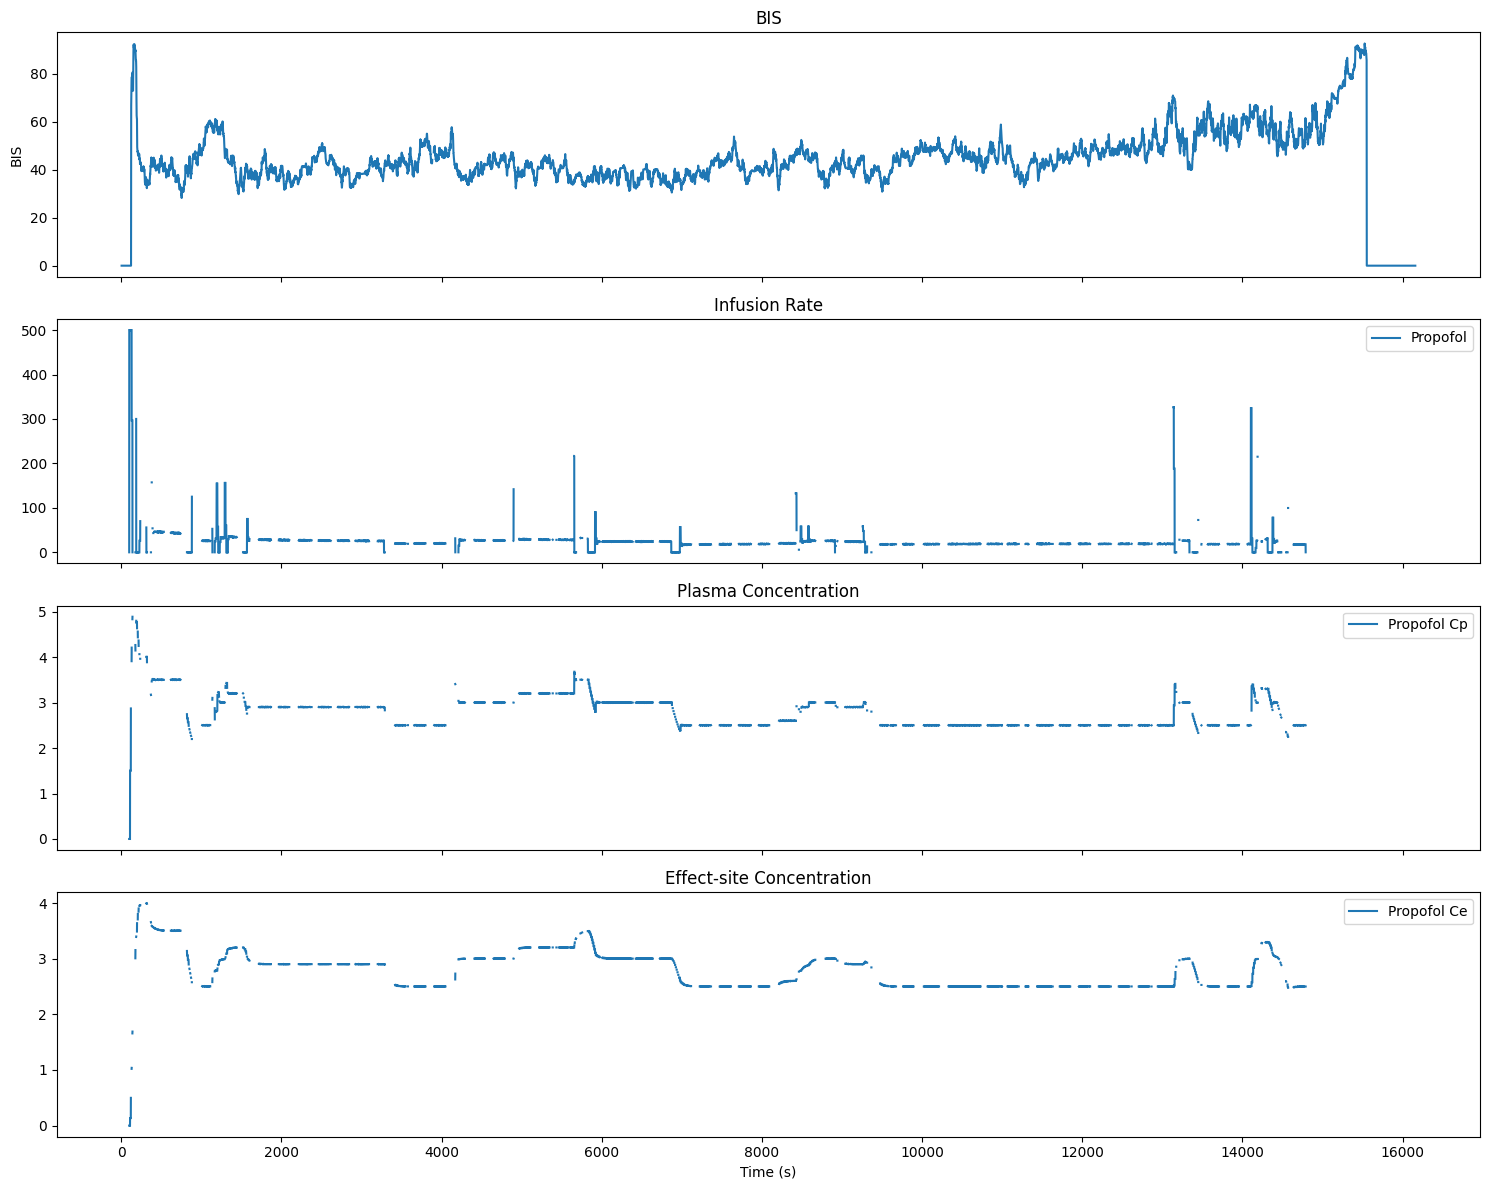

In [98]:
fig, ax = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# BIS
ax[0].plot(df["BIS/BIS"])
ax[0].set_title("BIS")
ax[0].set_ylabel("BIS")

# نرخ تزریق
ax[1].plot(df["Orchestra/PPF20_RATE"], label="Propofol")
ax[1].set_title("Infusion Rate")
ax[1].legend()

# غلظت Plasma
ax[2].plot(df["Orchestra/PPF20_CP"], label="Propofol Cp")
ax[2].set_title("Plasma Concentration")
ax[2].legend()

# غلظت Effect-site
ax[3].plot(df["Orchestra/PPF20_CE"], label="Propofol Ce")
ax[3].set_title("Effect-site Concentration")
ax[3].set_xlabel("Time (s)")
ax[3].legend()

plt.tight_layout()
plt.show()